# Eksplorasi Algoritma Face Recognition (MTCNN Detector) + Uji Skalabilitas

Notebook ini bertujuan untuk membandingkan delapan metode pengenalan wajah sesuai dengan uji yang dilakukan di sistem GUI:
1. **Geometry-Based (Geometric Landmarks)**
2. **PCA (Holistik)**
3. **LBP (Berbasis Fitur)**
4. **HOG (Berbasis Fitur)**
5. **LBP + PCA (Hibrida)**
6. **DeepFace - Facenet (Deep Learning)**
7. **DeepFace - VGG-Face (Deep Learning)**
8. **DeepFace - ArcFace (Deep Learning)**

Pengujian dilakukan dengan mencocokkan foto selfie kueri (Person A, B, C) dengan seluruh 1000 gambar uji di dataset, menggunakan metode pencocokan jarak Cosine langsung (tanpa SVM) seperti pada sistem GUI. Evaluasi akan mencari threshold optimal untuk masing-masing model untuk perbandingan yang adil.

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import time
import os
import psutil
import sys
import json
import hashlib
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from skimage.feature import local_binary_pattern, hog
from deepface import DeepFace
import pandas as pd

# Fungsi untuk mendapatkan penggunaan memori saat ini dalam MB
def get_memory_usage():
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024 ** 2)

# Menemukan project root
possible_roots = [
    os.path.abspath("."),
    os.path.abspath(".."),
    os.path.abspath("../..")
]
project_root = None
for root in possible_roots:
    if os.path.exists(os.path.join(root, "core")) and os.path.exists(os.path.join(root, "cache_io")):
        project_root = root
        break
if project_root is None:
    project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)
print(f"Project root diatur ke: {project_root}")

from src.core.detector import FaceDetector
from src.cache_io.cache_handler import CacheHandler


Project root diatur ke: c:\Users\vivobook\OneDrive\Documents\TA\personal_image_search


## 1. Persiapan Dataset & Integrasi Cache
Memuat dataset pengujian dari `D:\dataset\testset`, foto kueri dari `queries/`, ground truth dari `ground_truth.json`, dan inisialisasi model cache terpisah untuk masing-masing model Deep Learning menggunakan `CacheHandler` dari `cache_io`.

In [2]:
TESTSET_DIR = "D:/dataset/testset"
TEST_IMAGES_DIR = os.path.join(TESTSET_DIR, "test_case")
QUERIES_DIR = os.path.join(TESTSET_DIR, "queries")
GROUND_TRUTH_PATH = os.path.join(TESTSET_DIR, "ground_truth.json")

# 1. Load Ground Truth
with open(GROUND_TRUTH_PATH, "r", encoding="utf-8") as f:
    ground_truth = json.load(f)

test_images = [f for f in os.listdir(TEST_IMAGES_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
LIMIT_IMAGES = None  # Ganti dengan angka (misal 100) untuk pengujian cepat, atau None untuk seluruh gambar
if LIMIT_IMAGES is not None:
    test_images = test_images[:LIMIT_IMAGES]
print(f"Total Gambar Uji: {len(test_images)}")
print(f"Total Gambar di Ground Truth: {len(ground_truth)}")

# 2. Inisialisasi Face Detector
detector = FaceDetector("mtcnn")

# 3. Subclass CacheHandler untuk menentukan direktori cache secara dinamis per model
class ModelCacheHandler(CacheHandler):
    def __init__(self, folder_input_path: str, model_name: str):
        super().__init__(folder_input_path)
        self.model_name = model_name.lower()
        self.cache_dir = os.path.join(self.folder_input_path, f".face_cache_mtcnn_{self.model_name}")
        os.makedirs(self.cache_dir, exist_ok=True)

    def cache_exists(self, file_name: str, bbox: tuple) -> bool:
        bbox_str = f"_{bbox[0]}_{bbox[1]}_{bbox[2]}_{bbox[3]}"
        unique_id = hashlib.md5((file_name + bbox_str).encode('utf-8')).hexdigest()
        cache_file_path = os.path.join(self.cache_dir, f"{unique_id}.json")
        return os.path.exists(cache_file_path)

# 4. Load Preloaded Cache untuk efisiensi eksekusi notebook
models_dl = ["ArcFace", "Facenet", "VGG-Face"]
handlers = {model: ModelCacheHandler(TEST_IMAGES_DIR, model) for model in models_dl}
preloaded_caches = {}

for model in models_dl:
    print(f"Memuat cache untuk model {model}...")
    cache_list = handlers[model].muat_seluruh_cache()
    model_cache = {}
    for entry in cache_list:
        img_name = entry["file_name"]
        if img_name not in model_cache:
            model_cache[img_name] = []
        model_cache[img_name].append(entry)
    preloaded_caches[model] = model_cache

# 5. Helper untuk memuat wajah (face ROIs) — selalu menggunakan detector untuk alignment konsisten
def get_face_rois(img_path, detector):
    # Selalu jalankan detector.detect_and_crop agar affine alignment 5-titik diterapkan
    # secara konsisten di setiap run, tanpa bergantung pada cache bbox yang mungkin
    # dihasilkan oleh detector berbeda atau tanpa alignment.
    return detector.detect_and_crop(img_path)

def extract_deepface_embedding(face_img, model_name):
    if len(face_img.shape) == 2:
        face_img = cv2.cvtColor(face_img, cv2.COLOR_GRAY2BGR)
    elif face_img.shape[2] == 4:
        face_img = face_img[:, :, :3]
    # Downscale check for safe preprocessing
    h_f, w_f = face_img.shape[:2]
    if max(h_f, w_f) > 1080:
        scale_f = 1080.0 / max(h_f, w_f)
        face_img = cv2.resize(face_img, (int(w_f * scale_f), int(h_f * scale_f)), interpolation=cv2.INTER_AREA)
    objs = DeepFace.represent(
        img_path=face_img,
        model_name=model_name,
        enforce_detection=False,
        detector_backend="skip"
    )
    return np.array(objs[0]['embedding'], dtype=np.float32)

# 6. Ekstraksi Wajah untuk Kueri
queries = {
    "A": os.path.join(QUERIES_DIR, "selfie_A.jpeg"),
    "B": os.path.join(QUERIES_DIR, "selfie_B.jpg"),
    "C": os.path.join(QUERIES_DIR, "selfie_C.jpg")
}
query_faces = {}
for person, path in queries.items():
    faces = detector.detect_and_crop(path)
    if faces:
        query_faces[person] = faces[0]["cropped_face"]
        print(f"Wajah kueri Person {person} berhasil dideteksi.")
    else:
        raise RuntimeError(f"Gagal mendeteksi wajah pada kueri: {path}")

# 7. Kumpulkan semua wajah terdeteksi dari dataset gambar uji (Face Cropping tunggal untuk keadilan evaluasi)
print("Mengumpulkan wajah dari dataset gambar uji...")
t0 = time.time()
dataset_faces = [] # list of dict: {"img_name": str, "cropped_face": np.ndarray, "bbox": tuple}
for img_name in test_images:
    img_path = os.path.join(TEST_IMAGES_DIR, img_name)
    rois = get_face_rois(img_path, detector)
    for roi in rois:
        dataset_faces.append({
            "img_name": img_name,
            "cropped_face": roi["cropped_face"],
            "bbox": roi["bbox"]
        })
detection_time = time.time() - t0
print(f"Berhasil mengumpulkan {len(dataset_faces)} wajah dari {len(test_images)} gambar uji dalam {detection_time:.2f} detik (deteksi+alignment).")

# Penampung hasil komparasi
results = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': [],
    'Best Threshold': [],
    'Feature Extraction Time (s)': [],
    'Inference Time (s)': [],
    'Memory Usage (MB)': [],
    'Detection Time (s)': []
}

# Fungsi pembantu evaluasi umum
def evaluate_matching_model(model_name, query_feats, dataset_feats, dataset_face_metadata, feat_extract_time, mem_used):
    t0 = time.time()
    # Evaluasi jarak Cosine secara matriks/ter-vektorisasi
    # query_feats: dict of {person: vector}
    # dataset_feats: array of shape (N_faces, dim)
    
    persons = ["A", "B", "C"]
    # Hitung semua jarak Cosine antara kueri dan wajah di dataset
    # Jarak Cosine = 1.0 - Cosine Similarity
    distances = {}
    for p in persons:
        q_feat = query_feats[p]
        q_norm = q_feat / (np.linalg.norm(q_feat) + 1e-10)
        
        # dataset_feats shape (N, dim)
        ds_norms = np.linalg.norm(dataset_feats, axis=1, keepdims=True) + 1e-10
        ds_normed = dataset_feats / ds_norms
        
        sims = np.dot(ds_normed, q_norm)
        sims = np.clip(sims, -1.0, 1.0)
        distances[p] = 1.0 - sims
        
    # Mencari threshold optimal dari 0.05 ke 0.95 dengan step 0.05
    thresholds = np.arange(0.05, 1.0, 0.05)
    best_f1 = -1
    best_thresh = 0.4
    best_metrics = {}
    
    # Struktur data target (ground truth)
    # Bentuk ground truth flat (1000 gambar * 3 orang = 3000 pasang)
    y_true = []
    for img_name in test_images:
        gt_img = ground_truth.get(img_name, {"contains_person_A": False, "contains_person_B": False, "contains_person_C": False})
        y_true.append(gt_img.get("contains_person_A", False))
        y_true.append(gt_img.get("contains_person_B", False))
        y_true.append(gt_img.get("contains_person_C", False))
    y_true = np.array(y_true, dtype=bool)
    
    # Lakukan grid search threshold
    for thresh in thresholds:
        # Lakukan prediksi untuk setiap gambar uji
        y_pred = []
        for img_name in test_images:
            # Cari indeks wajah-wajah yang terdeteksi di gambar ini
            indices = [i for i, meta in enumerate(dataset_face_metadata) if meta["img_name"] == img_name]
            
            for p in persons:
                if not indices:
                    # Tidak ada wajah terdeteksi
                    y_pred.append(False)
                else:
                    # Ambil jarak terkecil (wajah paling mirip) untuk kueri person p
                    min_dist = np.min(distances[p][indices])
                    y_pred.append(min_dist <= thresh)
                    
        y_pred = np.array(y_pred, dtype=bool)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh
            best_metrics = {
                'Accuracy': accuracy_score(y_true, y_pred),
                'Precision': precision_score(y_true, y_pred, zero_division=0),
                'Recall': recall_score(y_true, y_pred, zero_division=0),
                'F1-Score': f1
            }
            
    infer_time = time.time() - t0
    
    # Catat ke tabel komparasi
    results['Model'].append(model_name)
    results['Accuracy'].append(best_metrics['Accuracy'])
    results['Precision'].append(best_metrics['Precision'])
    results['Recall'].append(best_metrics['Recall'])
    results['F1-Score'].append(best_metrics['F1-Score'])
    results['Best Threshold'].append(best_thresh)
    results['Feature Extraction Time (s)'].append(feat_extract_time)
    results['Inference Time (s)'].append(infer_time)
    results['Memory Usage (MB)'].append(mem_used)
    results['Detection Time (s)'].append(detection_time)
    
    print(f"--- {model_name} Evaluated ---")
    print(f"Best Threshold: {best_thresh:.2f}")
    print(f"Accuracy      : {best_metrics['Accuracy']:.4f}")
    print(f"F1-Score      : {best_metrics['F1-Score']:.4f}")

2026-07-01 20:17:11,001 - INFO - Menginisialisasi detektor wajah MTCNN...


Total Gambar Uji: 1000
Total Gambar di Ground Truth: 1000


Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "c:\Users\vivobook\OneDrive\Documents\TA\personal_image_search\venv\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "c:\Users\vivobook\OneDrive\Documents\TA\personal_image_search\venv\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "c:\Users\vivobook\OneDrive\Documents\TA\personal_image_search\venv\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
2026-07-01 20:17:11,494 - INFO - Detektor wajah MTCNN berhasil diinisialisasi.
2026-07-01 20:17:11,495 - INFO - Direktori cache Zero-DB siap di: D:\dataset\testset\test_

Memuat cache untuk model ArcFace...
Memuat cache untuk model Facenet...
Memuat cache untuk model VGG-Face...
Wajah kueri Person A berhasil dideteksi.
Wajah kueri Person B berhasil dideteksi.


2026-07-01 20:17:12,133 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).


Wajah kueri Person C berhasil dideteksi.
Mengumpulkan wajah dari dataset gambar uji...


2026-07-01 20:17:12,398 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-01 20:17:12,653 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-01 20:17:12,978 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-01 20:17:13,346 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-01 20:17:13,704 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-01 20:17:14,079 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-01 20:17:14,439 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-01 20:17:14,816 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-01 20:17:15,180 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-01

Berhasil mengumpulkan 6020 wajah dari 1000 gambar uji dalam 279.49 detik (deteksi+alignment).


## 2. Metode Berbasis Geometri: Geometry-Based Landmarks
Metode berbasis geometri mengidentifikasi wajah dengan mengukur jarak relatif antar landmark wajah utama seperti mata, hidung, dan mulut secara scale-invariant pada 6 jarak Euclidean berpasangan.

In [3]:
def extract_geometry_features(face_img):
    gray = cv2.cvtColor(face_img, cv2.COLOR_BGR2GRAY)
    h_idx, w_idx = gray.shape
    
    def get_landmark_centroid(y_start, y_end, x_start, x_end):
        ys, ye = int(y_start * h_idx), int(y_end * h_idx)
        xs, xe = int(x_start * w_idx), int(x_end * w_idx)
        sub_img = gray[ys:ye, xs:xe]
        
        threshold = np.percentile(sub_img, 10)
        dark_pixels = np.argwhere(sub_img <= threshold)
        if len(dark_pixels) == 0:
            cy, cx = (ys + ye) / 2, (xs + xe) / 2
        else:
            cy = ys + np.mean(dark_pixels[:, 0])
            cx = xs + np.mean(dark_pixels[:, 1])
        return np.array([cx, cy])
        
    left_eye = get_landmark_centroid(0.2, 0.4, 0.2, 0.45)
    right_eye = get_landmark_centroid(0.2, 0.4, 0.55, 0.8)
    nose = get_landmark_centroid(0.45, 0.7, 0.4, 0.6)
    mouth = get_landmark_centroid(0.7, 0.95, 0.3, 0.7)
    
    dists = [
        np.linalg.norm(left_eye - right_eye),
        np.linalg.norm(left_eye - nose),
        np.linalg.norm(right_eye - nose),
        np.linalg.norm(left_eye - mouth),
        np.linalg.norm(right_eye - mouth),
        np.linalg.norm(nose - mouth)
    ]
    
    eye_dist = dists[0] if dists[0] > 0 else 1.0
    normalized_dists = [d / eye_dist for d in dists]
    return np.array(normalized_dists, dtype=np.float32)

print("Evaluasi Geometry-Based...")
mem_before = get_memory_usage()
t0 = time.time()

query_feats = {p: extract_geometry_features(face) for p, face in query_faces.items()}
dataset_feats = np.array([extract_geometry_features(f["cropped_face"]) for f in dataset_faces])

feat_time = time.time() - t0
mem_after = get_memory_usage()
mem_used = max(0, mem_after - mem_before)

evaluate_matching_model('Geometry-Based', query_feats, dataset_feats, dataset_faces, feat_time, mem_used)

Evaluasi Geometry-Based...
--- Geometry-Based Evaluated ---
Best Threshold: 0.05
Accuracy      : 0.3450
F1-Score      : 0.4087


## 3. Metode Holistik: PCA (Eigenfaces)
Principal Component Analysis (PCA) mereduksi dimensi gambar dari wajah ter-resize dengan memproyeksikannya ke eigenfaces berdimensi 150.

In [4]:
print("Evaluasi PCA (Eigenfaces)... ")
mem_before = get_memory_usage()
t0 = time.time()

# 1. Flatten wajah ke grayscale
def flatten_gray_face(face_img):
    gray = cv2.cvtColor(face_img, cv2.COLOR_BGR2GRAY)
    return gray.flatten().astype(np.float32) / 255.0

query_flat = np.array([flatten_gray_face(query_faces[p]) for p in ["A", "B", "C"]])
dataset_flat = np.array([flatten_gray_face(f["cropped_face"]) for f in dataset_faces])

# 2. Fit PCA pada kumpulan wajah dataset
n_components = min(150, len(dataset_faces))
pca = PCA(n_components=n_components, svd_solver='randomized', whiten=True)
pca.fit(dataset_flat)

# 3. Proyeksi
query_projected = pca.transform(query_flat)
dataset_projected = pca.transform(dataset_flat)

query_feats = {p: query_projected[i] for i, p in enumerate(["A", "B", "C"])}

feat_time = time.time() - t0
mem_after = get_memory_usage()
mem_used = max(0, mem_after - mem_before)

evaluate_matching_model('PCA (Holistik)', query_feats, dataset_projected, dataset_faces, feat_time, mem_used)

Evaluasi PCA (Eigenfaces)... 
--- PCA (Holistik) Evaluated ---
Best Threshold: 0.95
Accuracy      : 0.5423
F1-Score      : 0.4421


## 4. Metode Berbasis Fitur: LBP & HOG
Mengekstrak fitur lokal menggunakan **Local Binary Pattern (LBP)** dan **Histogram of Oriented Gradients (HOG)**.

In [5]:
def extract_lbp_hist(face_img, radius=1, n_points=8):
    gray = cv2.cvtColor(face_img, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, n_points, radius, method="uniform")
    n_bins = n_points + 2
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)
    return hist.astype(np.float32)

print("Evaluasi LBP...")
mem_before = get_memory_usage()
t0 = time.time()

query_feats = {p: extract_lbp_hist(query_faces[p]) for p in ["A", "B", "C"]}
dataset_feats = np.array([extract_lbp_hist(f["cropped_face"]) for f in dataset_faces])

feat_time = time.time() - t0
mem_after = get_memory_usage()
mem_used = max(0, mem_after - mem_before)

evaluate_matching_model('LBP (Berbasis Fitur)', query_feats, dataset_feats, dataset_faces, feat_time, mem_used)

def extract_hog_vector(face_img):
    gray = cv2.cvtColor(face_img, cv2.COLOR_BGR2GRAY)
    feat = hog(gray, orientations=8, pixels_per_cell=(8, 8),
               cells_per_block=(2, 2), visualize=False)
    return feat.astype(np.float32)

print("\nEvaluasi HOG...")
mem_before = get_memory_usage()
t0 = time.time()

query_feats = {p: extract_hog_vector(query_faces[p]) for p in ["A", "B", "C"]}
dataset_feats = np.array([extract_hog_vector(f["cropped_face"]) for f in dataset_faces])

feat_time = time.time() - t0
mem_after = get_memory_usage()
mem_used = max(0, mem_after - mem_before)

evaluate_matching_model('HOG (Berbasis Fitur)', query_feats, dataset_feats, dataset_faces, feat_time, mem_used)

Evaluasi LBP...
--- LBP (Berbasis Fitur) Evaluated ---
Best Threshold: 0.25
Accuracy      : 0.4413
F1-Score      : 0.4256

Evaluasi HOG...
--- HOG (Berbasis Fitur) Evaluated ---
Best Threshold: 0.30
Accuracy      : 0.5740
F1-Score      : 0.4706


## 5. Metode Hibrida: LBP + PCA
Menggabungkan tekstur lokal dari LBP mentah dengan reduksi dimensi PCA (50 komponen).

In [6]:
def extract_raw_lbp(face_img, radius=1, n_points=8):
    gray = cv2.cvtColor(face_img, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, n_points, radius, method="uniform")
    return lbp.ravel().astype(np.float32)

print("Evaluasi LBP + PCA (Hibrida)...")
mem_before = get_memory_usage()
t0 = time.time()

query_raw_lbp = np.array([extract_raw_lbp(query_faces[p]) for p in ["A", "B", "C"]])
dataset_raw_lbp = np.array([extract_raw_lbp(f["cropped_face"]) for f in dataset_faces])

n_components_hyb = min(50, len(dataset_faces))
pca_lbp = PCA(n_components=n_components_hyb, svd_solver='randomized', whiten=True)
pca_lbp.fit(dataset_raw_lbp)

query_projected = pca_lbp.transform(query_raw_lbp)
dataset_projected = pca_lbp.transform(dataset_raw_lbp)

query_feats = {p: query_projected[i] for i, p in enumerate(["A", "B", "C"])}

feat_time = time.time() - t0
mem_after = get_memory_usage()
mem_used = max(0, mem_after - mem_before)

evaluate_matching_model('LBP + PCA (Hibrida)', query_feats, dataset_projected, dataset_faces, feat_time, mem_used)

Evaluasi LBP + PCA (Hibrida)...
--- LBP + PCA (Hibrida) Evaluated ---
Best Threshold: 0.95
Accuracy      : 0.4620
F1-Score      : 0.4173


## 6. Metode Deep Learning: Facenet (DeepFace)
Mengekstrak embedding berdimensi 128 dari model Deep Learning Facenet (diload dari cache jika tersedia).

In [7]:
print("Evaluasi Facenet...")
mem_before = get_memory_usage()
t0 = time.time()

# 1. Ekstraksi Fitur Kueri
query_feats = {}
for p in ["A", "B", "C"]:
    q_img = cv2.cvtColor(query_faces[p], cv2.COLOR_GRAY2BGR) if len(query_faces[p].shape) == 2 else query_faces[p]
    rep = DeepFace.represent(img_path=q_img, model_name="Facenet", enforce_detection=False, detector_backend="skip")
    query_feats[p] = np.array(rep[0]["embedding"], dtype=np.float32)

# 2. Ekstraksi Fitur Dataset
dataset_feats_list = []
for idx, face_meta in enumerate(dataset_faces):
    img_name = face_meta["img_name"]
    bbox = face_meta["bbox"]
    
    # Cek cache Facenet
    cached_found = False
    if img_name in preloaded_caches["Facenet"]:
        for cached_entry in preloaded_caches["Facenet"][img_name]:
            if list(cached_entry["bbox"]) == list(bbox):
                dataset_feats_list.append(cached_entry["embedding"])
                cached_found = True
                break
                
    if not cached_found:
        import gc
        # Ekstraksi Baru dan simpan cache
        f_img = face_meta["cropped_face"]
        emb = extract_deepface_embedding(f_img, "Facenet")
        norm = np.linalg.norm(emb)
        if norm > 0:
            emb = emb / norm
        handlers["Facenet"].simpan_cache(img_name, emb, bbox)
        dataset_feats_list.append(emb)
        del f_img, emb
        if idx % 100 == 0:
            gc.collect()
dataset_feats = np.array(dataset_feats_list)
feat_time = time.time() - t0
mem_after = get_memory_usage()
mem_used = max(0, mem_after - mem_before)

evaluate_matching_model('DeepFace (Facenet)', query_feats, dataset_feats, dataset_faces, feat_time, mem_used)

# Bersihkan session Keras untuk mengosongkan RAM sebelum memuat model berikutnya
import tensorflow as tf
tf.keras.backend.clear_session()
import gc
gc.collect()

Evaluasi Facenet...
--- DeepFace (Facenet) Evaluated ---
Best Threshold: 0.40
Accuracy      : 0.8743
F1-Score      : 0.7351


198

## 7. Metode Deep Learning: VGG-Face (DeepFace)
Mengekstrak embedding berdimensi 2622 dari model Deep Learning VGG-Face (diload dari cache jika tersedia).

In [8]:
print("Evaluasi VGG-Face...")
mem_before = get_memory_usage()
t0 = time.time()

# 1. Ekstraksi Fitur Kueri
query_feats = {}
for p in ["A", "B", "C"]:
    q_img = cv2.cvtColor(query_faces[p], cv2.COLOR_GRAY2BGR) if len(query_faces[p].shape) == 2 else query_faces[p]
    rep = DeepFace.represent(img_path=q_img, model_name="VGG-Face", enforce_detection=False, detector_backend="skip")
    query_feats[p] = np.array(rep[0]["embedding"], dtype=np.float32)

# 2. Ekstraksi Fitur Dataset
dataset_feats_list = []
for idx, face_meta in enumerate(dataset_faces):
    img_name = face_meta["img_name"]
    bbox = face_meta["bbox"]
    
    cached_found = False
    if img_name in preloaded_caches["VGG-Face"]:
        for cached_entry in preloaded_caches["VGG-Face"][img_name]:
            if list(cached_entry["bbox"]) == list(bbox):
                dataset_feats_list.append(cached_entry["embedding"])
                cached_found = True
                break
                
    if not cached_found:
        import gc
        f_img = face_meta["cropped_face"]
        emb = extract_deepface_embedding(f_img, "VGG-Face")
        norm = np.linalg.norm(emb)
        if norm > 0:
            emb = emb / norm
        handlers["VGG-Face"].simpan_cache(img_name, emb, bbox)
        dataset_feats_list.append(emb)
        del f_img, emb
        if idx % 50 == 0:
            gc.collect()
dataset_feats = np.array(dataset_feats_list)
feat_time = time.time() - t0
mem_after = get_memory_usage()
mem_used = max(0, mem_after - mem_before)

evaluate_matching_model('DeepFace (VGG-Face)', query_feats, dataset_feats, dataset_faces, feat_time, mem_used)

# Bersihkan session Keras untuk mengosongkan RAM sebelum memuat model berikutnya
import tensorflow as tf
tf.keras.backend.clear_session()
import gc
gc.collect()

Evaluasi VGG-Face...
--- DeepFace (VGG-Face) Evaluated ---
Best Threshold: 0.60
Accuracy      : 0.8943
F1-Score      : 0.7466


305

## 8. Metode Deep Learning: ArcFace (DeepFace)
Mengekstrak embedding berdimensi 512 dari model Deep Learning ArcFace (diload dari cache jika tersedia). Ini adalah model yang digunakan oleh sistem utama GUI.

In [9]:
print("Evaluasi ArcFace...")
mem_before = get_memory_usage()
t0 = time.time()

# 1. Ekstraksi Fitur Kueri
query_feats = {}
for p in ["A", "B", "C"]:
    q_img = cv2.cvtColor(query_faces[p], cv2.COLOR_GRAY2BGR) if len(query_faces[p].shape) == 2 else query_faces[p]
    rep = DeepFace.represent(img_path=q_img, model_name="ArcFace", enforce_detection=False, detector_backend="skip")
    query_feats[p] = np.array(rep[0]["embedding"], dtype=np.float32)

# 2. Ekstraksi Fitur Dataset
dataset_feats_list = []
for idx, face_meta in enumerate(dataset_faces):
    img_name = face_meta["img_name"]
    bbox = face_meta["bbox"]
    
    cached_found = False
    if img_name in preloaded_caches["ArcFace"]:
        for cached_entry in preloaded_caches["ArcFace"][img_name]:
            if list(cached_entry["bbox"]) == list(bbox):
                dataset_feats_list.append(cached_entry["embedding"])
                cached_found = True
                break
                
    if not cached_found:
        import gc
        f_img = face_meta["cropped_face"]
        emb = extract_deepface_embedding(f_img, "ArcFace")
        norm = np.linalg.norm(emb)
        if norm > 0:
            emb = emb / norm
        handlers["ArcFace"].simpan_cache(img_name, emb, bbox)
        dataset_feats_list.append(emb)
        del f_img, emb
        if idx % 50 == 0:
            gc.collect()
dataset_feats = np.array(dataset_feats_list)
feat_time = time.time() - t0
mem_after = get_memory_usage()
mem_used = max(0, mem_after - mem_before)

evaluate_matching_model('DeepFace (ArcFace)', query_feats, dataset_feats, dataset_faces, feat_time, mem_used)

# Bersihkan session Keras setelah selesai pengujian
import tensorflow as tf
tf.keras.backend.clear_session()
import gc
gc.collect()

Evaluasi ArcFace...


--- DeepFace (ArcFace) Evaluated ---
Best Threshold: 0.65
Accuracy      : 0.8610
F1-Score      : 0.7114


404

## 9. Visualisasi dan Perbandingan Kinerja
Menampilkan tabel perbandingan DataFrame lengkap untuk kedelapan model, dan memvisualisasikan F1-Score, waktu eksekusi total (ekstraksi + pencocokan), serta tambahan penggunaan RAM.


--- Hasil Perbandingan Lengkap (8 Model) ---
               Model  Accuracy  Precision   Recall  F1-Score  Best Threshold  Feature Extraction Time (s)  Inference Time (s)  Memory Usage (MB)  Detection Time (s)
      Geometry-Based  0.345000   0.259557 0.960396  0.408667            0.05                     1.698522            6.202859           0.781250           279.48695
      PCA (Holistik)  0.542333   0.310148 0.769448  0.442097            0.95                     4.007720            6.422600         292.859375           279.48695
LBP (Berbasis Fitur)  0.441333   0.280868 0.878359  0.425634            0.25                    11.091806            6.949630           0.597656           279.48695
HOG (Berbasis Fitur)  0.574000   0.332748 0.803395  0.470588            0.30                    15.903175            6.887330         113.621094           279.48695
 LBP + PCA (Hibrida)  0.462000   0.280175 0.817539  0.417329            0.95                     9.856407            6.657027    

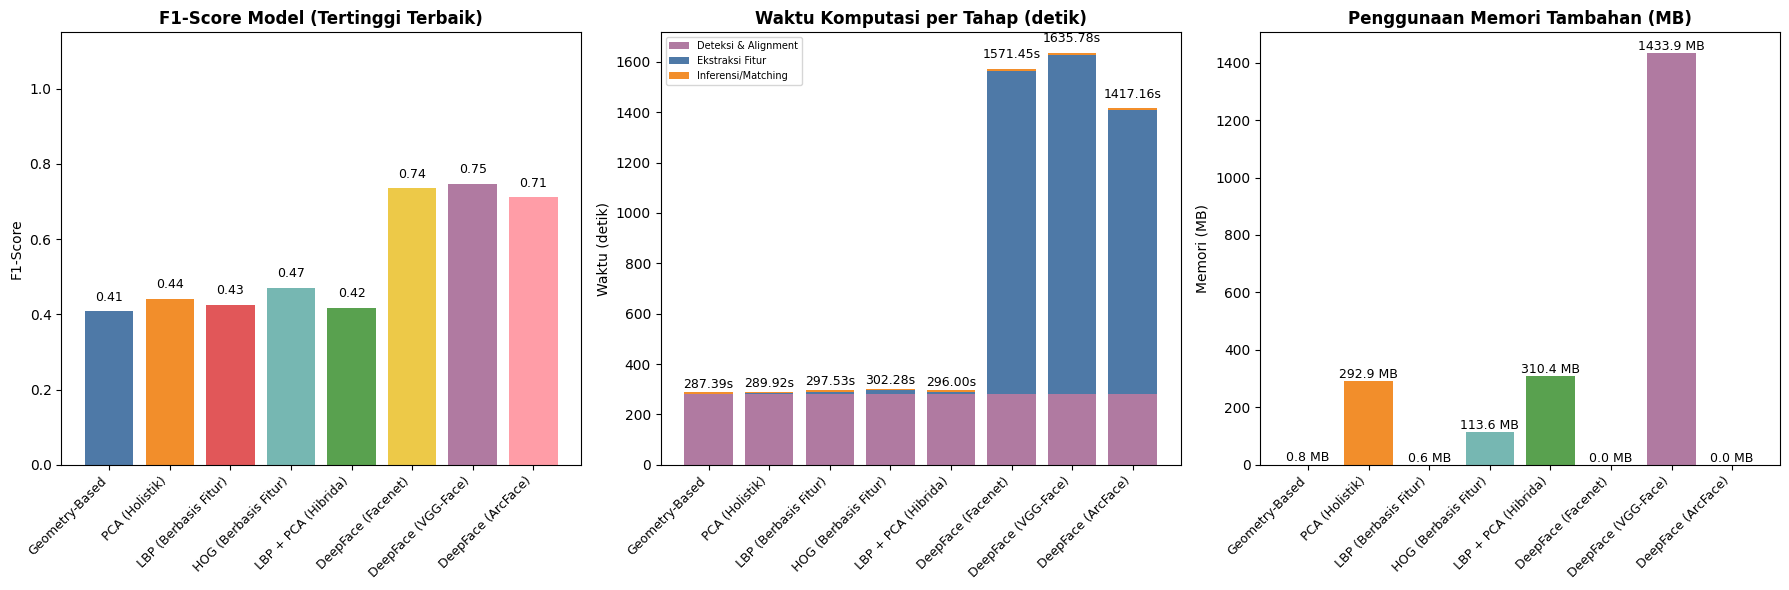

In [10]:
df_results = pd.DataFrame(results)
print("\n--- Hasil Perbandingan Lengkap (8 Model) ---")
print(df_results.to_string(index=False))

# Tableau 10 color palette untuk visualisasi premium
colors = ['#4E79A7', '#F28E2B', '#E15759', '#76B7B2', '#59A14F', '#EDC948', '#B07AA1', '#FF9DA7']

plt.figure(figsize=(18, 6))

# 1. Plot F1-Score
plt.subplot(1, 3, 1)
bars1 = plt.bar(df_results['Model'], df_results['F1-Score'], color=colors[:len(df_results)])
plt.title('F1-Score Model (Tertinggi Terbaik)', fontsize=12, fontweight='bold')
plt.ylim(0, 1.15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel('F1-Score')
for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f"{yval:.2f}", ha='center', va='bottom', fontsize=9)

# 2. Plot Stacked Waktu Komputasi per Tahap (Deteksi + Ekstraksi + Inferensi)
plt.subplot(1, 3, 2)
det_times = df_results['Detection Time (s)']
feat_times = df_results['Feature Extraction Time (s)']
infer_times = df_results['Inference Time (s)']
plt.bar(df_results['Model'], det_times, color='#B07AA1', label='Deteksi & Alignment')
plt.bar(df_results['Model'], feat_times, bottom=det_times, color='#4E79A7', label='Ekstraksi Fitur')
plt.bar(df_results['Model'], infer_times, bottom=det_times + feat_times, color='#F28E2B', label='Inferensi/Matching')
total_time = det_times + feat_times + infer_times
plt.title('Waktu Komputasi per Tahap (detik)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel('Waktu (detik)')
plt.legend(fontsize=7, loc='upper left')
for i, total in enumerate(total_time):
    plt.text(i, total + (total * 0.02) + 0.05, f"{total:.2f}s", ha='center', va='bottom', fontsize=9)

# 3. Plot Memory Usage
plt.subplot(1, 3, 3)
bars3 = plt.bar(df_results['Model'], df_results['Memory Usage (MB)'], color=colors[:len(df_results)])
plt.title('Penggunaan Memori Tambahan (MB)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel('Memori (MB)')
for bar in bars3:
    yval = bar.get_height()
    # Jaga formatting
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.1, f"{yval:.1f} MB", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
assets_dir = os.path.join(project_root, "assets")
os.makedirs(assets_dir, exist_ok=True)
plt.savefig(os.path.join(assets_dir, "perbandingan_kinerja_mtcnn.png"), dpi=300, bbox_inches="tight")
plt.show()

In [11]:
DETECTOR_TYPE = "mtcnn"


## 10. Uji Skalabilitas: Waktu Pemrosesan vs Jumlah Data

Bagian ini menguji ketiga model Deep Learning (**ArcFace**, **Facenet**, **VGG-Face**) pada lima ukuran dataset yang berbeda: 100, 300, 500, 700, dan 1000 gambar (`test_case_100` s.d. `test_case_700`, serta `test_case` untuk 1000 gambar). Untuk setiap ukuran data, dicatat waktu **deteksi & alignment wajah** serta waktu **ekstraksi fitur** per model, tanpa menggunakan cache, agar waktu yang terukur murni mencerminkan biaya komputasi untuk jumlah data tersebut.

In [12]:
SCALING_SIZES = [100, 300, 500, 700, 1000]
SCALING_MODELS = ["ArcFace", "Facenet", "VGG-Face"]

def get_scaling_dir(size):
    if size == 1000:
        return os.path.join(TESTSET_DIR, "test_case")
    return os.path.join(TESTSET_DIR, f"test_case_{size}")

scaling_results = {
    "Data Size": [],
    "Model": [],
    "Num Images": [],
    "Num Faces Detected": [],
    "Detection Time (s)": [],
    "Feature Extraction Time (s)": [],
    "Total Time (s)": []
}

In [13]:
import gc

for size in SCALING_SIZES:
    img_dir = get_scaling_dir(size)
    img_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    print(f"\n=== Ukuran Data: {size} ({len(img_files)} gambar ditemukan di {os.path.basename(img_dir)}) ===")

    # Deteksi & alignment wajah sekali per ukuran data, dipakai bersama oleh ketiga model
    t0 = time.time()
    scaling_faces = []
    for img_name in img_files:
        img_path = os.path.join(img_dir, img_name)
        rois = detector.detect_and_crop(img_path)
        for roi in rois:
            scaling_faces.append(roi["cropped_face"])
    det_time = time.time() - t0
    print(f"Deteksi: {len(scaling_faces)} wajah dalam {det_time:.2f} detik")

    for model_name in SCALING_MODELS:
        t0 = time.time()
        for face_img in scaling_faces:
            _ = extract_deepface_embedding(face_img, model_name)
        feat_time = time.time() - t0

        scaling_results["Data Size"].append(size)
        scaling_results["Model"].append(model_name)
        scaling_results["Num Images"].append(len(img_files))
        scaling_results["Num Faces Detected"].append(len(scaling_faces))
        scaling_results["Detection Time (s)"].append(det_time)
        scaling_results["Feature Extraction Time (s)"].append(feat_time)
        scaling_results["Total Time (s)"].append(det_time + feat_time)

        print(f"  {model_name}: ekstraksi {feat_time:.2f} detik (total {det_time + feat_time:.2f} detik)")
        gc.collect()

    del scaling_faces
    gc.collect()

import tensorflow as tf
tf.keras.backend.clear_session()
gc.collect()

2026-07-01 21:26:15,056 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).



=== Ukuran Data: 100 (100 gambar ditemukan di test_case_100) ===


2026-07-01 21:26:15,487 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-01 21:26:15,864 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-01 21:26:16,271 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-01 21:26:16,643 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-01 21:26:16,974 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-01 21:26:17,281 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-01 21:26:17,595 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-01 21:26:17,942 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-01 21:26:18,585 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-01

Deteksi: 570 wajah dalam 39.69 detik
  ArcFace: ekstraksi 132.05 detik (total 171.74 detik)
  Facenet: ekstraksi 114.26 detik (total 153.95 detik)


2026-07-01 21:32:57,803 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).


...

2026-07-01 23:26:27,891 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).



=== Ukuran Data: 1000 (1000 gambar ditemukan di test_case) ===


2026-07-01 23:26:28,232 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-01 23:26:28,546 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-01 23:26:28,900 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-01 23:26:29,257 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-01 23:26:29,613 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-01 23:26:29,944 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-01 23:26:30,282 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-01 23:26:30,642 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-01 23:26:31,033 - INFO - Gambar resolusi tinggi di-downscale dari 1108x1477 ke 810x1080 (max 1080px).
2026-07-01

Deteksi: 6020 wajah dalam 341.39 detik
  ArcFace: ekstraksi 1346.50 detik (total 1687.89 detik)
  Facenet: ekstraksi 1142.77 detik (total 1484.16 detik)
  VGG-Face: ekstraksi 1620.66 detik (total 1962.05 detik)


107


--- Hasil Uji Skalabilitas (Waktu vs Jumlah Data) ---
 Data Size    Model  Num Images  Num Faces Detected  Detection Time (s)  Feature Extraction Time (s)  Total Time (s)
       100  ArcFace         100                 570           39.694456                   132.048711      171.743166
       100  Facenet         100                 570           39.694456                   114.259325      153.953781
       100 VGG-Face         100                 570           39.694456                   116.017421      155.711876
       300  ArcFace         300                2360          104.329924                   407.960043      512.289967
       300  Facenet         300                2360          104.329924                   521.202161      625.532085
       300 VGG-Face         300                2360          104.329924                   574.814339      679.144263
       500  ArcFace         500                3134          167.250384                   560.384227      727.634611
       50

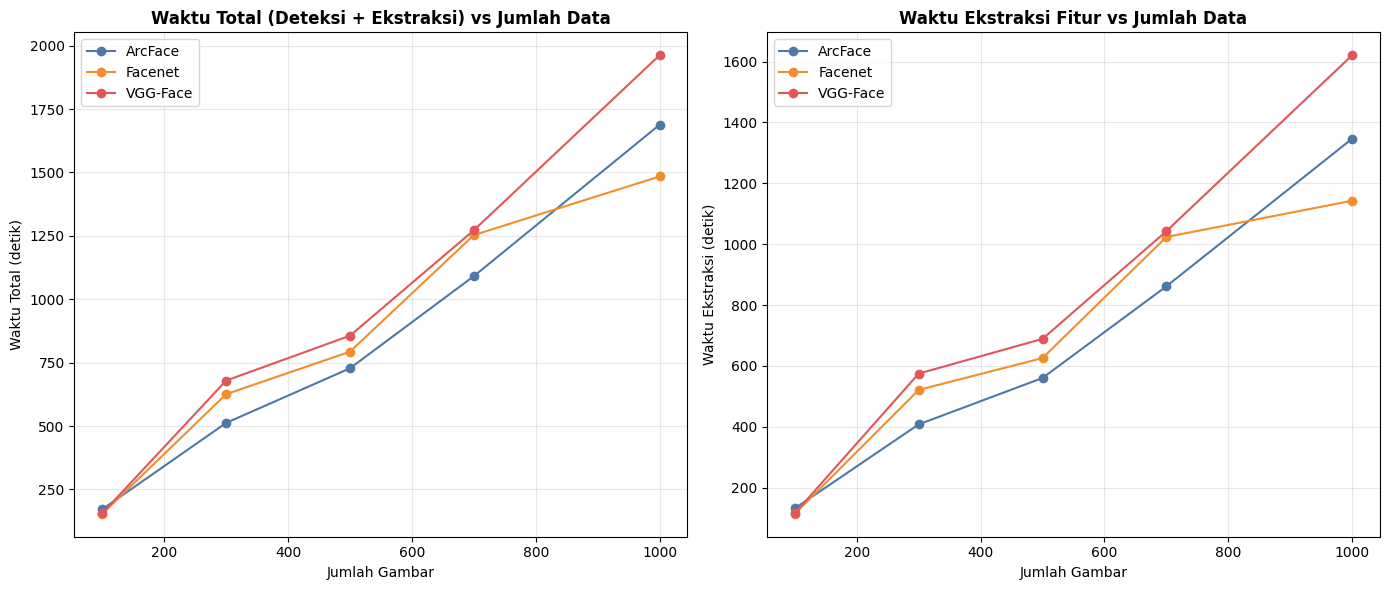

In [14]:
df_scaling = pd.DataFrame(scaling_results)
print("\n--- Hasil Uji Skalabilitas (Waktu vs Jumlah Data) ---")
print(df_scaling.to_string(index=False))

scaling_colors = {'ArcFace': '#4E79A7', 'Facenet': '#F28E2B', 'VGG-Face': '#E15759'}

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
for model_name in SCALING_MODELS:
    subset = df_scaling[df_scaling["Model"] == model_name]
    plt.plot(subset["Data Size"], subset["Total Time (s)"], marker='o', label=model_name, color=scaling_colors[model_name])
plt.title("Waktu Total (Deteksi + Ekstraksi) vs Jumlah Data", fontsize=12, fontweight="bold")
plt.xlabel("Jumlah Gambar")
plt.ylabel("Waktu Total (detik)")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
for model_name in SCALING_MODELS:
    subset = df_scaling[df_scaling["Model"] == model_name]
    plt.plot(subset["Data Size"], subset["Feature Extraction Time (s)"], marker='o', label=model_name, color=scaling_colors[model_name])
plt.title("Waktu Ekstraksi Fitur vs Jumlah Data", fontsize=12, fontweight="bold")
plt.xlabel("Jumlah Gambar")
plt.ylabel("Waktu Ekstraksi (detik)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
assets_dir = os.path.join(project_root, "assets")
os.makedirs(assets_dir, exist_ok=True)
plt.savefig(os.path.join(assets_dir, f"uji_skalabilitas_{DETECTOR_TYPE}.png"), dpi=300, bbox_inches="tight")
plt.show()